# Notebook 2: Methodology, results and discussion

This notebook trains SARIMA, an LSTM and a TCN on each of the three busiest squares and evaluates them one step ahead, walk-forward, over Dec 16–22, 2013. It only reads the files saved by `01_data_and_eda.ipynb`.

In [1]:
import os
import platform
import time
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
import psutil
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.nn.utils.parametrizations import weight_norm
from statsmodels.tsa.statespace.sarimax import SARIMAX

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

PROCESSED_DIR = Path("../data/processed")
FIGURES_DIR = Path("../figures")
RESULTS_DIR = Path("../results")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cpu")

wide = pd.read_parquet(PROCESSED_DIR / "timeseries_selected_squares.parquet")
ranking_df = pd.read_csv(RESULTS_DIR / "square_ranking.csv")
SERIES_EPOCH = wide.index[0]
top3_ids = ranking_df.iloc[:3]["square_id"].tolist()
top3_cols = [f"square_{sid}" for sid in top3_ids]
print("Top-3 squares (from Notebook 1):", top3_ids)
print("Series shape:", wide.shape, "| range:", wide.index.min(), "->", wide.index.max())

TRAIN_START = "2013-11-01 00:00"
NOV_END = "2013-11-30 23:50"
VAL_START = "2013-12-01 00:00"
TRAIN_END = "2013-12-15 23:50"
TEST_START, TEST_END = "2013-12-16 00:00", "2013-12-22 23:50"
test_index = wide.loc[TEST_START:TEST_END].index
print(f"Test week: {test_index.min()} -> {test_index.max()} ({len(test_index)} ten-minute steps)")

hardware_info = {
    "platform": platform.platform(),
    "processor": platform.processor() or platform.machine(),
    "cpu_count": os.cpu_count(),
    "ram_gb": round(psutil.virtual_memory().total / 1024 ** 3, 1),
    "torch_threads": torch.get_num_threads(),
    "device": "CPU (no GPU used)",
}
print("Hardware:", hardware_info)

Top-3 squares (from Notebook 1): [5161, 5059, 5259]
Series shape: (8928, 5) | range: 2013-11-01 00:00:00 -> 2014-01-01 23:50:00
Test week: 2013-12-16 00:00:00 -> 2013-12-22 23:50:00 (1008 ten-minute steps)
Hardware: {'platform': 'Windows-10-10.0.26200-SP0', 'processor': 'Intel64 Family 6 Model 186 Stepping 2, GenuineIntel', 'cpu_count': 16, 'ram_gb': 7.7, 'torch_threads': 10, 'device': 'CPU (no GPU used)'}


## Methodology

### Literature review

[1] G. Barlacchi, M. De Nadai, R. Larcher, et al., "A multi-source dataset of urban life in the city of Milan and the Province of Trentino," *Scientific Data*, vol. 2, no. 150055, 2015. Describes the Telecom Italia dataset used here (telecommunications, weather, news, social network and electricity data for Milan and Trentino).

[2] A. Azari, P. Papapetrou, S. Denic, and G. Peters, "Cellular Traffic Prediction and Classification: A Comparative Evaluation of LSTM and ARIMA," in *Proc. 22nd Int. Conf. Discovery Science (DS)*, Split, Croatia, 2019, pp. 129-144. Compares LSTM and ARIMA on cellular traffic. It finds LSTM better in general, especially with large and fine-grained training data, while ARIMA comes close in some cases at a much lower cost. This is why the project compares a classical model with a recurrent one instead of using only one of them.

[3] W. Wang, C. Zhou, H. He, W. Wu, W. Zhuang, and X. Shen, "Cellular Traffic Load Prediction with LSTM and Gaussian Process Regression," in *Proc. IEEE Int. Conf. Commun. (ICC)*, Dublin, Ireland, Jun. 2020, pp. 1-6. Combines an LSTM with Gaussian process regression to predict single-cell traffic on the Milan data, which supports using an LSTM for each square here.

[4] C. Zhang and P. Patras, "Long-Term Mobile Traffic Forecasting Using Deep Spatio-Temporal Neural Networks," in *Proc. ACM MobiHoc*, Los Angeles, CA, 2018, pp. 231-240. Proposes a deep spatio-temporal neural network for network-wide mobile traffic forecasting, evaluated on real traffic data collected over 60 days. It models many areas jointly, which this project does not do (see the Conclusion).

[5] S. Bai, J. Z. Kolter, and V. Koltun, "An Empirical Evaluation of Generic Convolutional and Recurrent Networks for Sequence Modeling," *arXiv:1803.01271*, 2018. Introduces the TCN (stacked dilated causal convolutions with residual connections) and reports that it outperforms canonical recurrent networks such as LSTMs on a range of sequence tasks, with longer effective memory. The third model here is a TCN written from scratch.

**Model choice.** The three models come from different families (statistical, recurrent, convolutional).
- **SARIMA**: a classical baseline. The EDA shows a strong daily cycle for square 5161 (STL seasonal strength 0.858, ACF peaks at lag 144), which seasonal terms can describe directly [2]. Limitation: the seasonal shape is a fixed number of harmonics, so it cannot adapt to a day that looks different.
- **LSTM**: a recurrent network on a one-day window, as in [3]. Limitation: it has to learn the daily shape from about 6,500 training points per square.
- **TCN**: a dilated convolutional network. The ACF of square 5161 is still 0.77 at lag 288 and 0.74 at lag 432, and the TCN used here has a receptive field of 253 steps, longer than the 144-step input window [5]. Limitation: it took longer to train than the LSTM on two of the three squares (see Results), although it has fewer parameters (9,185 against 18,241).

### Input representation, preprocessing and training

**Common setup.** One model per model type and square (9 in total). Training data is Nov 1 – Dec 15; the test week is Dec 16–22 (1,008 ten-minute steps), evaluated walk-forward one step at a time, always from true past values and never from the model's own predictions. The SARIMA settings are chosen for each square by AIC on the training data. The LSTM and TCN settings are chosen on square 5161 only, using Dec 1–15 as a validation set that the search never trains on, and are then reused for the other two squares. `compute_metrics()` (MAE, MAPE, RMSE), the windowing functions and the training and search functions are defined once and used for every model and square.

**SARIMA.** The input is the raw series (about 6,480 training points per square). Seasonality enters through Fourier terms used as exogenous regressors (harmonics at the daily period of 144 steps and at the weekly period of 1,008) together with a non-seasonal `(p,d,q)` ARIMA, so this is a regression with ARIMA errors rather than a `SARIMAX` model with seasonal orders. I still call it SARIMA. The version with seasonal orders was too slow (see iteration 1 below). The number of harmonics and the ARIMA order are chosen by AIC in two stages (see iteration 2). In the walk-forward evaluation the fitted model is updated with each true observation using `append(..., refit=False)` and then forecasts the next step. The Fourier terms only depend on time, so they are computed for the whole test week in advance.

**LSTM.** The input is a window of the previous steps (the window length is one of the searched settings, see the tuning log). Each step has 5 features: the traffic value, z-scored with the mean and standard deviation of that square, and sin/cos of the time of day and of the day of week. During the search the mean and standard deviation come from November only; for the final models they come from Nov 1 – Dec 15. A recurrent layer (`nn.LSTM`, number of layers searched) followed by a linear layer on the last hidden state predicts the next normalized value, which is converted back to the original scale. Training uses Adam, MSE loss, batch size 64 and 20 epochs. Hidden size, learning rate, number of layers and window length come from the grid search.

**TCN.** Same input as the LSTM. Written from scratch in PyTorch: 6 residual blocks with dilations 1, 2, 4, 8, 16, 32, weight-normalized causal convolutions, ReLU and dropout, a 1×1 convolution on the skip path when the number of channels changes, and a linear layer on the last time step [5]. Training is the same as for the LSTM (Adam, MSE loss, batch size 64, 20 epochs). Channels per block, dropout, kernel size and learning rate come from the grid search.

**Timing.** Each training and inference time is a single measurement (`time.perf_counter()`, one run per model and square), not an average over repeated runs. They change noticeably between runs and even within a run: in the latest run the LSTM took about 61 s on two squares and 312 s on the third with the same model and epochs. Only large differences are therefore meaningful. All runs used the same CPU (printed above).

In [2]:
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    eps = 1e-6
    mape = float(np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), eps, None))) * 100)
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}


def time_features(index):
    # sin/cos of time of day and of day of week
    hour_frac = index.hour + index.minute / 60
    dow = index.dayofweek
    return np.stack([
        np.sin(2 * np.pi * hour_frac / 24), np.cos(2 * np.pi * hour_frac / 24),
        np.sin(2 * np.pi * dow / 7), np.cos(2 * np.pi * dow / 7),
    ], axis=1).astype("float32")


def make_windows(values_norm, feats, L):
    # X: (N, L, 1+F) windows of value + time features, y: the value right after each window
    N = len(values_norm) - L
    X = np.zeros((N, L, 1 + feats.shape[1]), dtype="float32")
    y = np.zeros(N, dtype="float32")
    for i in range(N):
        X[i, :, 0] = values_norm[i:i + L]
        X[i, :, 1:] = feats[i:i + L]
        y[i] = values_norm[i + L]
    return X, y


def windows_for_targets(norm, start, end, L):
    # windows whose targets lie in [start, end]; each needs L steps of history before its target
    part = norm.loc[pd.Timestamp(start) - pd.Timedelta(minutes=10 * L):end]
    return make_windows(part.values, time_features(part.index), L)


def build_datasets(col, L):
    full = wide[col]
    nov = full.loc[TRAIN_START:NOV_END]
    train = full.loc[TRAIN_START:TRAIN_END]
    # grid search: normalise with November statistics only, so December stays unseen
    norm_search = (full - nov.mean()) / nov.std()
    # final models: normalise with Nov 1 - Dec 15 statistics
    mu, sigma = train.mean(), train.std()
    norm_final = (full - mu) / sigma

    tr = norm_search.loc[TRAIN_START:NOV_END]
    X_tr, y_tr = make_windows(tr.values, time_features(tr.index), L)
    X_val, y_val = windows_for_targets(norm_search, VAL_START, TRAIN_END, L)
    tf = norm_final.loc[TRAIN_START:TRAIN_END]
    X_full, y_full = make_windows(tf.values, time_features(tf.index), L)
    X_test, _ = windows_for_targets(norm_final, TEST_START, TEST_END, L)
    return dict(X_tr=X_tr, y_tr=y_tr, X_val=X_val, y_val=y_val, X_full=X_full, y_full=y_full,
                X_test=X_test, mu=mu, sigma=sigma)


class Timer:
    def __enter__(self):
        self.t0 = time.perf_counter()
        return self

    def __exit__(self, *exc):
        self.elapsed = time.perf_counter() - self.t0


EPOCHS = 20  # the same for the grid search and the final training
timing_records = []


def train_torch_model(model, X_train, y_train, epochs, lr, batch_size=64):
    model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    Xt = torch.tensor(X_train, device=DEVICE)
    yt = torch.tensor(y_train, device=DEVICE)
    n = len(Xt)
    for _ in range(epochs):
        perm = torch.randperm(n)
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            opt.zero_grad()
            loss = loss_fn(model(Xt[idx]), yt[idx])
            loss.backward()
            opt.step()
    return model


@torch.no_grad()
def predict_torch_model(model, X):
    model.eval()
    return model(torch.tensor(X, device=DEVICE)).cpu().numpy()


def validation_mse(make_model, lr, data):
    # train on November, score on Dec 1-15
    torch.manual_seed(SEED)
    model = train_torch_model(make_model(), data["X_tr"], data["y_tr"], epochs=EPOCHS, lr=lr)
    return float(np.mean((predict_torch_model(model, data["X_val"]) - data["y_val"]) ** 2))


def fit_final(name, make_model, lr):
    # train one model per square on Nov 1 - Dec 15 and predict the test week from true history windows
    preds = {}
    for sid in top3_ids:
        ds = nn_datasets[sid]
        torch.manual_seed(SEED)
        with Timer() as t_train:
            model = train_torch_model(make_model(), ds["X_full"], ds["y_full"], epochs=EPOCHS, lr=lr)
        timing_records.append({"model": name, "square_id": sid, "phase": "train_total_s", "seconds": round(t_train.elapsed, 2)})
        with Timer() as t_inf:
            pred_norm = predict_torch_model(model, ds["X_test"])
        preds[sid] = pd.Series(pred_norm * ds["sigma"] + ds["mu"], index=test_index)
        timing_records.append({"model": name, "square_id": sid, "phase": "walkforward_inference_total_s", "seconds": round(t_inf.elapsed, 3)})
        print(f"Square {sid}: {name} trained in {t_train.elapsed:.1f}s, inference in {t_inf.elapsed:.3f}s")
    return preds

## Model 1: SARIMA

**Tuning log, iteration 1 (failed).** I first used the seasonal terms of `SARIMAX` directly, `(P,D,Q,s=144)`, with a grid of 4 `(p,d,q)(P,D,Q,144)` combinations for each of the three squares, fitted on the last 3 weeks before the test week. The cell had not finished after 3,600 s, when the timeout stopped it. The state-space size of a seasonal `SARIMAX` grows with the seasonal period, and at `s=144` the fits were too slow for a grid search. I did not measure how long a single fit takes. **Change:** model the seasonality with Fourier terms as exogenous regressors (dynamic harmonic regression) and fit only a non-seasonal `(p,d,q)`, so the state space no longer depends on `s`.

In [3]:
def fourier_terms(index, period, order):
    # sin/cos harmonics, phase-aligned to the start of the series so train and test stay in phase
    steps = ((index - SERIES_EPOCH) / pd.Timedelta(minutes=10)).astype(float)
    cols = {}
    for k in range(1, order + 1):
        cols[f"sin_p{period}_k{k}"] = np.sin(2 * np.pi * k * steps / period)
        cols[f"cos_p{period}_k{k}"] = np.cos(2 * np.pi * k * steps / period)
    return pd.DataFrame(cols, index=index)


def build_seasonal_exog(index, daily_k, weekly_k):
    # daily harmonics (period 144) + weekly harmonics (period 1008)
    return pd.concat([fourier_terms(index, 144, daily_k), fourier_terms(index, 1008, weekly_k)], axis=1)


def fit_sarimax(train_s, order, daily_k, weekly_k):
    mod = SARIMAX(train_s, exog=build_seasonal_exog(train_s.index, daily_k, weekly_k), order=order,
                  enforce_stationarity=False, enforce_invertibility=False)
    with Timer() as t:
        res = mod.fit(disp=False)
    return res, t.elapsed


sarima_orders = [(1, 0, 0), (2, 0, 0), (1, 0, 1), (2, 1, 1)]
fourier_grid = list(product([2, 4, 6, 8], [2, 4, 6]))  # (daily harmonics, weekly harmonics)

sarima_rows, sarima_fitted, sarima_fourier = [], {}, {}
for sid, col in zip(top3_ids, top3_cols):
    train_s = wide.loc[TRAIN_START:TRAIN_END, col]
    square_rows = []

    # stage 1: number of harmonics, with the ARIMA order fixed at (2,1,1)
    stage1 = {}
    for dk, wk in fourier_grid:
        res, sec = fit_sarimax(train_s, (2, 1, 1), dk, wk)
        stage1[(dk, wk)] = res
        square_rows.append({"square_id": sid, "stage": 1, "order": "(2,1,1)", "daily_harmonics": dk,
                            "weekly_harmonics": wk, "aic": res.aic, "fit_seconds": round(sec, 2)})
    dk, wk = min(stage1, key=lambda key: stage1[key].aic)
    best_order, best_fit = (2, 1, 1), stage1[(dk, wk)]

    # stage 2: ARIMA order, with the best harmonics (the (2,1,1) fit is the stage 1 winner)
    for order in sarima_orders:
        if order == (2, 1, 1):
            continue
        res, sec = fit_sarimax(train_s, order, dk, wk)
        square_rows.append({"square_id": sid, "stage": 2, "order": str(order).replace(" ", ""), "daily_harmonics": dk,
                            "weekly_harmonics": wk, "aic": res.aic, "fit_seconds": round(sec, 2)})
        if res.aic < best_fit.aic:
            best_order, best_fit = order, res

    sarima_rows += square_rows
    sarima_fitted[sid], sarima_fourier[sid] = best_fit, (dk, wk)
    timing_records.append({"model": "SARIMA", "square_id": sid, "phase": "train_grid_search_total_s",
                           "seconds": round(sum(r["fit_seconds"] for r in square_rows), 2)})
    print(f"Square {sid}: {dk} daily + {wk} weekly harmonics, order {best_order}, AIC={best_fit.aic:.1f}")

sarima_search_df = pd.DataFrame(sarima_rows)
sarima_search_df.to_csv(RESULTS_DIR / "sarima_grid_search.csv", index=False)
sarima_search_df

C:\Users\EVOTECH SOL\Desktop\Time-Series-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
C:\Users\EVOTECH SOL\Desktop\Time-Series-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)


C:\Users\EVOTECH SOL\Desktop\Time-Series-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
C:\Users\EVOTECH SOL\Desktop\Time-Series-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)


C:\Users\EVOTECH SOL\Desktop\Time-Series-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
C:\Users\EVOTECH SOL\Desktop\Time-Series-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)


C:\Users\EVOTECH SOL\Desktop\Time-Series-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
C:\Users\EVOTECH SOL\Desktop\Time-Series-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)


C:\Users\EVOTECH SOL\Desktop\Time-Series-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
C:\Users\EVOTECH SOL\Desktop\Time-Series-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)


...

C:\Users\EVOTECH SOL\Desktop\Time-Series-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
C:\Users\EVOTECH SOL\Desktop\Time-Series-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)


C:\Users\EVOTECH SOL\Desktop\Time-Series-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
C:\Users\EVOTECH SOL\Desktop\Time-Series-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)


C:\Users\EVOTECH SOL\Desktop\Time-Series-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
C:\Users\EVOTECH SOL\Desktop\Time-Series-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)


Square 5259: 8 daily + 6 weekly harmonics, order (2, 1, 1), AIC=82619.2


,square_id,stage,order,daily_harmonics,weekly_harmonics,aic,fit_seconds
0,5161,1,"(2,1,1)",2,2,88119.168089,1.37
1,5161,1,"(2,1,1)",2,4,88126.478550,1.67
2,5161,1,"(2,1,1)",2,6,88105.688049,2.20
3,5161,1,"(2,1,1)",4,2,88020.776913,2.02
4,5161,1,"(2,1,1)",4,4,88028.018262,2.23
5,5161,1,"(2,1,1)",4,6,88003.359124,3.17
6,5161,1,"(2,1,1)",6,2,87988.964647,2.75
7,5161,1,"(2,1,1)",6,4,87996.156081,3.20
8,5161,1,"(2,1,1)",6,6,87970.119634,3.47
9,5161,1,"(2,1,1)",8,2,87983.617655,3.18


**Tuning log, iteration 2 (used).** The search has two stages per square, both by AIC on the Nov 1 – Dec 15 training data (table above). Stage 1 fixes the ARIMA order at `(2,1,1)` and varies the number of harmonics: 2, 4, 6 or 8 daily and 2, 4 or 6 weekly (12 fits). More harmonics lowered the AIC on all three squares compared with the 4 daily and 2 weekly harmonics I used first (by about 56 on 5161, 156 on 5059 and 378 on 5259). The best combination was 6 daily and 6 weekly harmonics for 5059 and 8 daily and 6 weekly for 5161 and 5259. These values are at the edge of the grid, so more harmonics might fit even better; I did not test this. Stage 2 keeps the best harmonics and compares the ARIMA orders `(1,0,0)`, `(2,0,0)`, `(1,0,1)` and `(2,1,1)`; `(2,1,1)` had the lowest AIC on all three squares. Each fit took a few seconds, so the full Nov 1 – Dec 15 history (about 6,480 points) could be used instead of the 3 weeks used in iteration 1.

In [4]:
# walk-forward: forecast one step, then update the filter with the true value (no refit)
sarima_preds = {}

for sid, col in zip(top3_ids, top3_cols):
    model = sarima_fitted[sid]
    test_s = wide.loc[TEST_START:TEST_END, col]
    test_exog = build_seasonal_exog(test_s.index, *sarima_fourier[sid])
    preds = []
    with Timer() as t_inf:
        current = model
        for (t, actual), (_, exog_row) in zip(test_s.items(), test_exog.iterrows()):
            forecast = current.forecast(1, exog=[exog_row.values])
            preds.append(float(forecast.iloc[0]))
            current = current.append([actual], exog=[exog_row.values], refit=False)
    sarima_preds[sid] = pd.Series(preds, index=test_s.index)
    timing_records.append({"model": "SARIMA", "square_id": sid, "phase": "walkforward_inference_total_s",
                           "seconds": round(t_inf.elapsed, 2)})
    print(f"Square {sid}: SARIMA walk-forward done in {t_inf.elapsed:.1f}s for {len(test_s)} steps")

Square 5161: SARIMA walk-forward done in 54.9s for 1008 steps


Square 5059: SARIMA walk-forward done in 52.6s for 1008 steps


Square 5259: SARIMA walk-forward done in 52.0s for 1008 steps


## Model 2: LSTM

In [5]:
class LSTMForecaster(nn.Module):
    def __init__(self, n_features, hidden_size, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden_size, num_layers=num_layers, batch_first=True)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):  # (batch, seq_len, n_features)
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze(-1)

In [6]:
# grid search on square 5161 (top-1) only; the best setting is used for all three squares
rep_col = top3_cols[0]
WINDOWS = (72, 144, 288)
search_data = {L: build_datasets(rep_col, L) for L in WINDOWS}
n_features = search_data[144]["X_tr"].shape[2]

lstm_rows = []


def run_lstm(stage, hidden_size, lr, num_layers, window):
    with Timer() as t:
        mse = validation_mse(lambda: LSTMForecaster(n_features, hidden_size, num_layers), lr, search_data[window])
    lstm_rows.append({"stage": stage, "hidden_size": hidden_size, "lr": lr, "num_layers": num_layers,
                      "window": window, "val_mse": mse, "seconds": round(t.elapsed, 1)})


# stage 1: hidden size x learning rate (1 layer, window 144)
for hidden_size, lr in product([32, 64, 128], [1e-3, 5e-3]):
    run_lstm(1, hidden_size, lr, 1, 144)
best1 = min(lstm_rows, key=lambda r: r["val_mse"])

# stage 2: number of layers and window length, around the best stage 1 setting
for num_layers, window in [(2, 144), (1, 72), (1, 288)]:
    run_lstm(2, best1["hidden_size"], best1["lr"], num_layers, window)
best_lstm = min(lstm_rows, key=lambda r: r["val_mse"])

lstm_search_df = pd.DataFrame(lstm_rows)
lstm_search_df.to_csv(RESULTS_DIR / "lstm_grid_search.csv", index=False)
print("Selected LSTM setting:", best_lstm)
lstm_search_df.sort_values("val_mse")

Selected LSTM setting: {'stage': 1, 'hidden_size': 64, 'lr': 0.005, 'num_layers': 1, 'window': 144, 'val_mse': 0.022702397778630257, 'seconds': 36.1}


,stage,hidden_size,lr,num_layers,window,val_mse,seconds
3,1,64,0.005,1,144,0.022702,36.1
4,1,128,0.001,1,144,0.023452,66.5
2,1,64,0.001,1,144,0.024309,31.7
5,1,128,0.005,1,144,0.025033,67.0
1,1,32,0.005,1,144,0.025881,20.4
6,2,64,0.005,2,144,0.026903,84.1
8,2,64,0.005,1,288,0.027206,350.7
0,1,32,0.001,1,144,0.029074,16.6
7,2,64,0.005,1,72,0.035659,19.7


**Tuning log, LSTM.** All settings were trained for 20 epochs, the same as in the final training, on square 5161 using November only (with November mean and standard deviation for the normalization) and scored by MSE on Dec 1–15 (table above). Stage 1 varied the hidden size (32, 64, 128) and the learning rate (1e-3, 5e-3) with one layer and a 144-step window. The best was hidden size 64 with learning rate 5e-3 (validation MSE 0.0227). 128 units were slightly worse (0.0235 at 1e-3 and 0.0250 at 5e-3) and 32 units clearly worse (0.0259 to 0.0291). Stage 2 kept this setting and changed one thing at a time: two layers (0.0269), a 72-step window (0.0357) and a 288-step window (0.0272) were all worse than one layer with 144 steps, so the setting stays at one layer and a 144-step window. The 288-step window also took about 10 times longer to train (351 s against 36 s). The search uses November only so that December is a real held-out set; the final models are then trained on the whole Nov 1 – Dec 15 period with the selected setting, with separate weights for each square.

In [7]:
# final datasets use the window length selected for the LSTM; the TCN uses the same input
WINDOW = int(best_lstm["window"])
nn_datasets = {sid: build_datasets(col, WINDOW) for sid, col in zip(top3_ids, top3_cols)}
print("Windowed datasets built for squares:", list(nn_datasets.keys()), "| window:", WINDOW)
print("Example shapes (top-1 square): X_full", nn_datasets[top3_ids[0]]["X_full"].shape,
      "X_test", nn_datasets[top3_ids[0]]["X_test"].shape)

lstm_preds = fit_final("LSTM", lambda: LSTMForecaster(n_features, int(best_lstm["hidden_size"]), int(best_lstm["num_layers"])),
                       best_lstm["lr"])

Windowed datasets built for squares: [5161, 5059, 5259] | window: 144
Example shapes (top-1 square): X_full (6336, 144, 5) X_test (1008, 144, 5)


Square 5161: LSTM trained in 60.8s, inference in 0.061s


Square 5059: LSTM trained in 61.7s, inference in 0.065s


Square 5259: LSTM trained in 311.5s, inference in 0.089s


## Model 3: TCN (hand-implemented, dilated causal convolutions)

In [8]:
DILATIONS = [1, 2, 4, 8, 16, 32]


class Chomp1d(nn.Module):
    # drops the extra right-hand padding so the convolution stays causal
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size] if self.chomp_size > 0 else x


class TemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size, dilation, dropout=0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        self.conv1 = weight_norm(nn.Conv1d(n_inputs, n_outputs, kernel_size, padding=padding, dilation=dilation))
        self.chomp1, self.relu1, self.drop1 = Chomp1d(padding), nn.ReLU(), nn.Dropout(dropout)
        self.conv2 = weight_norm(nn.Conv1d(n_outputs, n_outputs, kernel_size, padding=padding, dilation=dilation))
        self.chomp2, self.relu2, self.drop2 = Chomp1d(padding), nn.ReLU(), nn.Dropout(dropout)
        self.net = nn.Sequential(self.conv1, self.chomp1, self.relu1, self.drop1,
                                 self.conv2, self.chomp2, self.relu2, self.drop2)
        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None
        self.relu = nn.ReLU()

    def forward(self, x):  # (batch, channels, seq_len)
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)


class TCNForecaster(nn.Module):
    def __init__(self, n_inputs, channels, dilations, kernel_size=3, dropout=0.2):
        super().__init__()
        assert len(dilations) == len(channels), "need one dilation per block"
        layers = []
        for i, out_ch in enumerate(channels):
            in_ch = n_inputs if i == 0 else channels[i - 1]
            layers.append(TemporalBlock(in_ch, out_ch, kernel_size, dilations[i], dropout))
        self.tcn = nn.Sequential(*layers)
        self.head = nn.Linear(channels[-1], 1)

    def forward(self, x):  # (batch, seq_len, n_features), transposed to channels-first below
        y = self.tcn(x.transpose(1, 2))
        return self.head(y[:, :, -1]).squeeze(-1)


def receptive_field(kernel_size):
    return 1 + 2 * (kernel_size - 1) * sum(DILATIONS)


print(f"TCN receptive field: {receptive_field(3)} steps with kernel size 3, {receptive_field(5)} with kernel size 5 (window length {WINDOW})")

TCN receptive field: 253 steps with kernel size 3, 505 with kernel size 5 (window length 144)


In [9]:
# grid search on square 5161 (top-1) only, with the window length selected for the LSTM
tcn_rows = []


def run_tcn(stage, width, dropout, kernel_size, lr):
    make_model = lambda: TCNForecaster(n_features, [width] * len(DILATIONS), DILATIONS, kernel_size, dropout)
    with Timer() as t:
        mse = validation_mse(make_model, lr, search_data[WINDOW])
    tcn_rows.append({"stage": stage, "width": width, "dropout": dropout, "kernel_size": kernel_size,
                     "lr": lr, "val_mse": mse, "seconds": round(t.elapsed, 1)})


# stage 1: channels per block x dropout (kernel size 3, learning rate 1e-3)
for width, dropout in product([16, 32], [0.1, 0.2]):
    run_tcn(1, width, dropout, 3, 1e-3)
best1 = min(tcn_rows, key=lambda r: r["val_mse"])

# stage 2: kernel size and learning rate, around the best stage 1 setting
for kernel_size, lr in [(5, 1e-3), (3, 3e-3), (5, 3e-3)]:
    run_tcn(2, best1["width"], best1["dropout"], kernel_size, lr)
best_tcn = min(tcn_rows, key=lambda r: r["val_mse"])

tcn_search_df = pd.DataFrame(tcn_rows)
tcn_search_df.to_csv(RESULTS_DIR / "tcn_grid_search.csv", index=False)
print("Selected TCN setting:", best_tcn)
tcn_search_df.sort_values("val_mse")

Selected TCN setting: {'stage': 1, 'width': 16, 'dropout': 0.2, 'kernel_size': 3, 'lr': 0.001, 'val_mse': 0.02266157977283001, 'seconds': 82.6}


,stage,width,dropout,kernel_size,lr,val_mse,seconds
1,1,16,0.2,3,0.001,0.022662,82.6
3,1,32,0.2,3,0.001,0.022834,149.6
0,1,16,0.1,3,0.001,0.024159,91.6
2,1,32,0.1,3,0.001,0.024853,255.7
5,2,16,0.2,3,0.003,0.026508,90.8
6,2,16,0.2,5,0.003,0.038118,1061.4
4,2,16,0.2,5,0.001,0.043747,93.5


**Tuning log, TCN.** The settings were trained for 20 epochs on square 5161 (November only) and scored on Dec 1–15, using the 144-step window selected for the LSTM (table above). Stage 1 varied the channels per block (16, 32) and the dropout (0.1, 0.2) with kernel size 3 and learning rate 1e-3. The best was 16 channels with dropout 0.2 (validation MSE 0.0227). 32 channels with dropout 0.2 was almost the same (0.0228), and dropout 0.1 was worse for both widths (0.0242 and 0.0249). Stage 2 kept 16 channels and dropout 0.2 and changed the kernel size and the learning rate: kernel size 5 (0.0437 at 1e-3 and 0.0381 at 3e-3) and kernel size 3 with learning rate 3e-3 (0.0265) were all worse, so the final setting is kernel size 3 and learning rate 1e-3. The dilations were not tuned; with kernel size 3 they give a receptive field of 253 steps, which covers the 144-step window. One setting (kernel size 5, learning rate 3e-3) took 1,061 s while the others took 83 to 256 s; I did not find out why, background load is a likely cause. The final models are trained on Nov 1 – Dec 15 with this setting, with separate weights for each square. The selected network has 9,185 parameters, against 18,241 for the LSTM.

In [10]:
tcn_preds = fit_final("TCN", lambda: TCNForecaster(n_features, [int(best_tcn["width"])] * len(DILATIONS), DILATIONS,
                                                   int(best_tcn["kernel_size"]), best_tcn["dropout"]),
                      best_tcn["lr"])

Square 5161: TCN trained in 130.4s, inference in 0.098s


Square 5059: TCN trained in 113.0s, inference in 0.085s


Square 5259: TCN trained in 121.3s, inference in 0.086s


**Walk-forward for the LSTM and TCN.** Every input window is built from true past values only, so predicting the whole test week in one batch gives the same result as predicting one step at a time and appending the true value each time. The models never see their own predictions. SARIMA is different: it is a recursive filter, so its state is updated with each true observation before the next forecast (see above).

## Results and Discussion

In [11]:
actuals = {sid: wide.loc[TEST_START:TEST_END, col] for sid, col in zip(top3_ids, top3_cols)}
model_preds = {"SARIMA": sarima_preds, "LSTM": lstm_preds, "TCN": tcn_preds}

metrics_rows = []
for sid in top3_ids:
    for model_name, preds in model_preds.items():
        m = compute_metrics(actuals[sid].values, preds[sid].values)
        metrics_rows.append({"square_id": sid, "model": model_name, **m})
metrics_df = pd.DataFrame(metrics_rows)

for sid in top3_ids:
    sub = metrics_df[metrics_df["square_id"] == sid][["model", "MAE", "MAPE", "RMSE"]].set_index("model")
    sub.to_csv(RESULTS_DIR / f"metrics_square_{sid}.csv")

metrics_df.pivot(index="square_id", columns="model", values=["MAE", "MAPE", "RMSE"])

MAE                             MAPE                       \
model           LSTM     SARIMA        TCN       LSTM    SARIMA        TCN   
square_id                                                                    
5059       73.581794  69.544776  78.989656   7.853869  7.666798   9.037673   
5161       98.868534  82.700672  87.922253  17.151704  9.425280   9.980031   
5259       71.822428  68.652928  72.308340   9.772336  9.095090  10.424773   

                 RMSE                          
model            LSTM      SARIMA         TCN  
square_id                                      
5059       101.362367   97.822193  106.073568  
5161       129.173881  122.783296  130.901782  
5259        96.860562   92.861608   96.105463

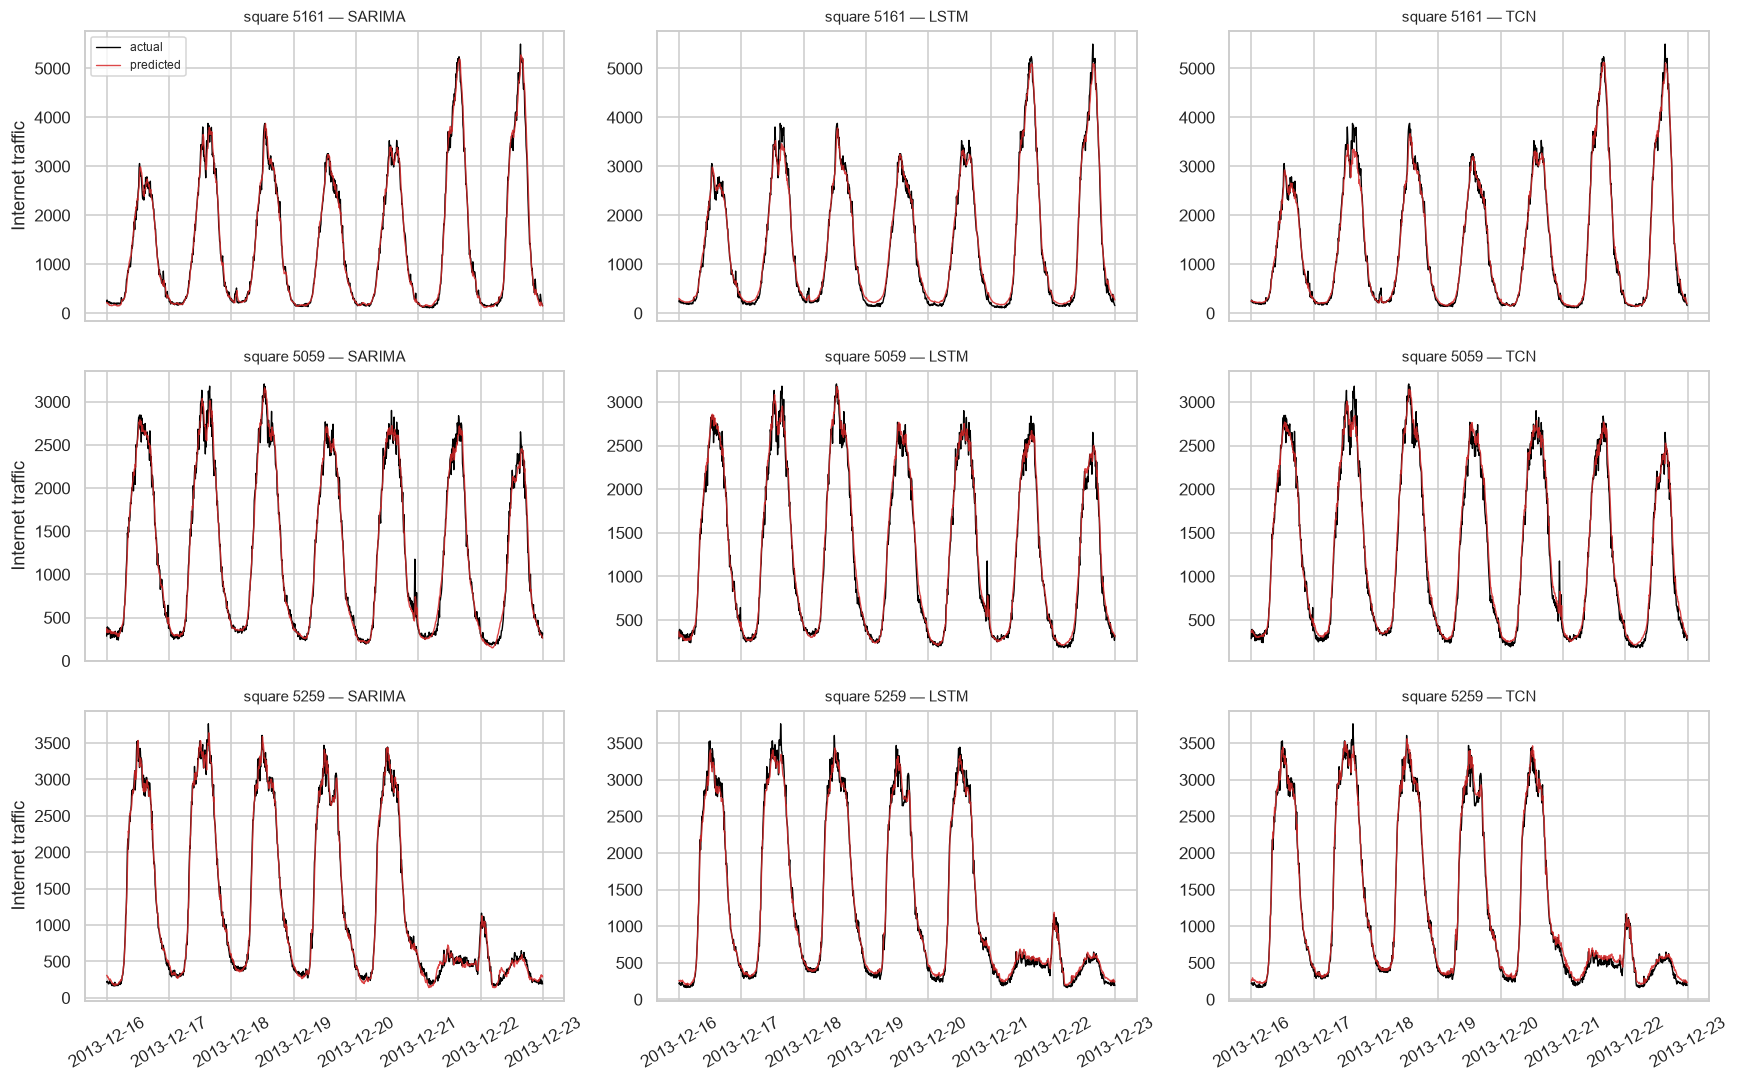

Saved 1 combined 3x3 grid figure + 9 individual actual-vs-predicted figures to figures/


In [12]:
def plot_forecast(ax, sid, model_name):
    ax.plot(actuals[sid].index, actuals[sid].values, label="actual", color="black", linewidth=0.9)
    ax.plot(model_preds[model_name][sid].index, model_preds[model_name][sid].values,
            label="predicted", color="tab:red", linewidth=0.9, alpha=0.85)


fig, axes = plt.subplots(3, 3, figsize=(16, 10), sharex=True)
for i, sid in enumerate(top3_ids):
    for j, model_name in enumerate(model_preds):
        plot_forecast(axes[i, j], sid, model_name)
        axes[i, j].set_title(f"square {sid} — {model_name}", fontsize=10)
        if i == 2:
            axes[i, j].tick_params(axis="x", rotation=30)
        if j == 0:
            axes[i, j].set_ylabel("Internet traffic")
axes[0, 0].legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "results_actual_vs_predicted_grid.png", bbox_inches="tight")
plt.show()

# one figure per model and square
for sid in top3_ids:
    for model_name in model_preds:
        fig, ax = plt.subplots(figsize=(10, 3.5))
        plot_forecast(ax, sid, model_name)
        ax.set_title(f"Actual vs. predicted — square {sid} — {model_name} (walk-forward, Dec 16-22)")
        ax.legend()
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / f"results_{model_name}_{sid}.png", bbox_inches="tight")
        plt.close(fig)
print("Saved 1 combined 3x3 grid figure + 9 individual actual-vs-predicted figures to figures/")

In [13]:
timing_df = pd.DataFrame(timing_records)
timing_df["hardware"] = hardware_info["processor"]
timing_df["ram_gb"] = hardware_info["ram_gb"]
timing_df["device"] = hardware_info["device"]
timing_df.to_csv(RESULTS_DIR / "timing.csv", index=False)

timing_df.pivot_table(index=["model", "phase"], values="seconds", aggfunc=["sum", "mean"])

sum        mean
                                      seconds     seconds
model  phase                                             
LSTM   train_total_s                  433.950  144.650000
       walkforward_inference_total_s    0.215    0.071667
SARIMA train_grid_search_total_s      176.400   58.800000
       walkforward_inference_total_s  159.590   53.196667
TCN    train_total_s                  364.640  121.546667
       walkforward_inference_total_s    0.269    0.089667

In [14]:
from statsmodels.tsa.seasonal import STL

for col in top3_cols:
    res = STL(wide[col], period=144, robust=True).fit()
    print(f"{col}: seasonal strength {1 - res.resid.var() / (res.seasonal + res.resid).var():.3f}")

square_5161: seasonal strength 0.858


square_5059: seasonal strength 0.891


square_5259: seasonal strength 0.497


**Discussion.** SARIMA is the best model on all three squares by MAE, MAPE and RMSE, but not by a large margin: on each square the MAE of the best neural model is only 4.6% to 6.3% higher than SARIMA's.

- **5161:** SARIMA (MAE 82.7, MAPE 9.4%, RMSE 122.8) is followed by the TCN (87.9, 10.0%, 130.9) and the LSTM (98.9, 17.2%, 129.2). The LSTM has the worst MAE and MAPE but a lower RMSE than the TCN.
- **5059:** SARIMA (69.5, 7.7%, 97.8), then the LSTM (73.6, 7.9%, 101.4) and the TCN (79.0, 9.0%, 106.1).
- **5259:** SARIMA (68.7, 9.1%, 92.9), then the LSTM (71.8, 9.8%, 96.9) and the TCN (72.3, 10.4%, 96.1). The two neural models are close to each other here.

The STL table above shows that the daily seasonal strength (0.858, 0.891 and 0.497) does not explain these differences: SARIMA leads by a similar amount on all three squares although 5259 has a much weaker daily seasonality. A possible reason is that SARIMA also has weekly Fourier terms, which describe the different weekday and weekend levels of the squares directly (see the time series plots in the EDA); I did not test this. The LSTM's MAPE on 5161 (17.2%) is much higher than its MAE suggests. In the figures the LSTM's predictions for 5161 stay above the actual values in the overnight troughs (roughly 250–300 predicted against 150–200 actual, judged by eye). MAPE divides by the actual value, so these small absolute errors at low traffic raise its MAPE more than its MAE.

This differs from the general result in [2], where the LSTM was better than ARIMA. One possible reason is the small training set here (about 6,300 windows per square), but I did not test that.

**Effect of the tuning.** The results of an earlier run with a smaller search are in the git history. With the earlier fixed harmonics (4 daily and 2 weekly) the SARIMA MAE was 81.9 on 5161, 70.6 on 5059 and 71.7 on 5259. With the searched harmonics it is 82.7, 69.5 and 68.7, so a lower AIC did not always mean a lower test error (5161 got slightly worse). The LSTM setting did not change and its results are identical. The TCN changed from 32 to 16 channels and improved on every square (MAE 97.8 to 87.9 on 5161, 87.6 to 79.0 on 5059 and 72.6 to 72.3 on 5259).

**Training time.** The TCN took 113–130 s per square. The LSTM took 61 to 62 s on 5161 and 5059 and 312 s on 5259 with the same model and epochs (probably background load, which I did not check). The SARIMA search took 47–66 s per square for its 15 fits. These are single runs and vary between runs (see Methodology), so only the order of magnitude is meaningful.

**Inference time.** SARIMA's walk-forward is sequential (1,008 filter updates per square) and took 52–55 s per square. The LSTM and TCN predict the whole week in one batch (under 0.1 s).

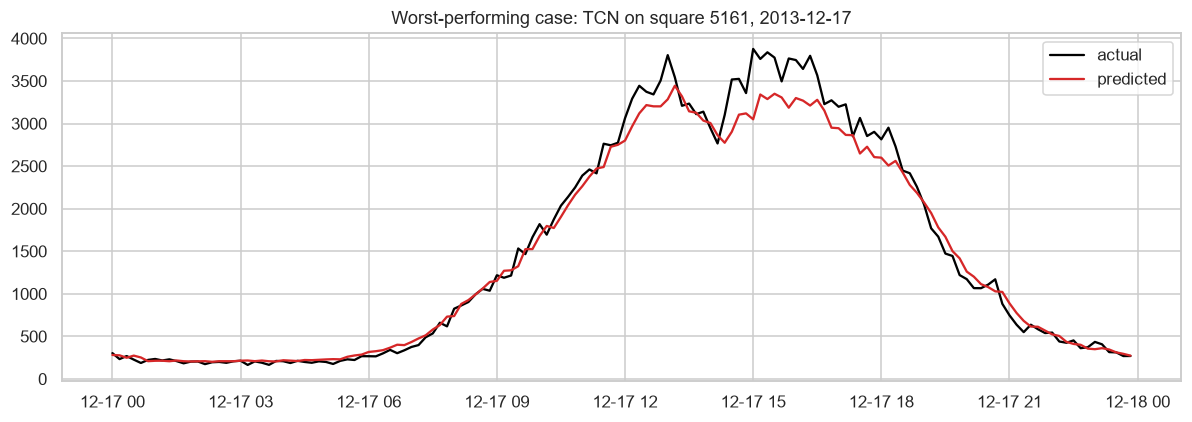

Worst combination overall: model=TCN, square=5161, RMSE=130.902
Worst single day within that combination's test week: 2013-12-17 (mean abs. error 122.309)


In [15]:
# worst (model, square) pair by RMSE, and its worst day
worst_row = metrics_df.loc[metrics_df["RMSE"].idxmax()]
worst_model, worst_sid = worst_row["model"], int(worst_row["square_id"])
err = (actuals[worst_sid] - model_preds[worst_model][worst_sid]).abs()
worst_day = err.resample("D").mean().idxmax()
window = slice(worst_day, worst_day + pd.Timedelta(hours=23, minutes=50))

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(actuals[worst_sid].loc[window].index, actuals[worst_sid].loc[window].values, label="actual", color="black")
ax.plot(model_preds[worst_model][worst_sid].loc[window].index, model_preds[worst_model][worst_sid].loc[window].values,
        label="predicted", color="tab:red")
ax.set_title(f"Worst-performing case: {worst_model} on square {worst_sid}, {worst_day.date()}")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "results_worst_case.png", bbox_inches="tight")
plt.show()

print(f"Worst combination overall: model={worst_model}, square={worst_sid}, RMSE={worst_row['RMSE']:.3f}")
print(f"Worst single day within that combination's test week: {worst_day.date()} (mean abs. error {err.resample('D').mean().max():.3f})")

**Worst case.** By RMSE the worst model/square pair is the TCN on square 5161 (RMSE 130.9), and its worst day is Tuesday Dec 17 (mean absolute error 122.3). The plot shows that the prediction follows the daily curve but stays below the actual values around the midday peak (about 12:00 to 17:00), by up to about 500. The actual peak that day (about 3,900) is higher than the peak of the day before (about 3,000, see the Dec 16 part of the TCN plot for 5161). I did not test why the TCN misses this peak.

The LSTM has a lower RMSE on this square (129.2) but a higher MAE and MAPE than the TCN (98.9 and 17.2% against 87.9 and 10.0%). RMSE weights large errors more, so the metrics imply that the TCN's errors are concentrated in fewer, larger misses, like the peak above, while the LSTM makes more small ones, for example in the overnight troughs. I did not analyse the error distributions further.